# HR-ETE-GNN Pilot Demonstration

**Hurst-Regime Adaptive Graph Neural Network with Effective Rényi Transfer Entropy**

*A scaled-down proof-of-concept pilot that demonstrates each component of the proposed methodology end-to-end on a small subset of the data, so panelists can see the pipeline run.*

---

##What is Volatility and What Are We Predicting?

### What is volatility?
**Volatility** measures how much an asset's price *fluctuates* over time. It is *not* the direction (up or down), but the *magnitude* of the swings. A stock that quietly drifts +0.1% each day has very low volatility; a stock that swings ±5% daily has very high volatility — even if both end the year at the same price.

Mathematically, given daily log-returns $r_t = \ln(p_t / p_{t-1})$, the **Realized Volatility (RV)** over the past $n$ trading days is:

$$RV_t = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(100\, r_{t-i})^2}$$

We use $n = 20$ days (≈ 1 trading month). RV is essentially the standard deviation of recent returns, scaled to percent.

### Why does it matter?
Volatility is the **unit of risk** in finance. It feeds directly into:
- **Value-at-Risk (VaR)** — how much could I lose tomorrow with 99% confidence?
- **Options pricing** — Black-Scholes uses volatility as its primary input.
- **Portfolio allocation** — risk-parity, mean-variance optimization.
- **Margin requirements** — brokers raise margin when volatility rises.

If we can forecast tomorrow's volatility better — *especially during a crisis* — we can size positions, hedge, and set risk limits more accurately.

### What exactly are we predicting?
**One-day-ahead Realized Volatility** for each of 10 country ETFs. That is, given everything we know up to today (day $t$), predict $RV_{t+1}$ for each country.

### Why a graph? Why Rényi?
Country markets are **interconnected** — a shock in Germany affects Brazil hours later. A **graph** lets us encode "who influences whom." The edges of that graph are computed from **Transfer Entropy**, an information-theoretic measure of directional information flow.

Standard (Shannon) Transfer Entropy weights *all* events equally — a normal day and a crash count the same. **Rényi Transfer Entropy** has a tunable parameter $\alpha$:
- $\alpha < 1$ → amplifies **rare tail events** (crashes, spikes)
- $\alpha = 1$ → recovers Shannon TE
- $\alpha > 1$ → emphasizes typical events

**Hypothesis:** during crisis regimes (detected via the Hurst exponent), $\alpha < 1$ should outperform Shannon TE.

---

## Pilot scope
This notebook is a **demonstration of feasibility**, not the full thesis run:
- 10 ETFs, but only ~5 years of daily data (vs. 19 years in the manuscript)
- Small α-grid: {0.5, 1.0, 1.5}
- Few surrogates (m=20) — manuscript uses more
- Short training (50 epochs)
- One regime split, no rolling retraining

The goal is to show every component **runs and produces sensible output**.


## 1. Setup & imports

Install dependencies if needed:

In [ ]:
 %pip install yfinance numpy pandas scikit-learn scipy matplotlib torch --quiet

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.special import gamma as gamma_fn
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

## 2. Data acquisition via yfinance

We download the 10 country iShares MSCI ETFs from the manuscript plus the MSCI World ETF (URTH) used as the regime proxy.

In [ ]:
TICKERS = ['EWA', 'EWC', 'EWG', 'EWJ', 'EWT', 'EWU', 'EWW', 'EWY', 'EWZ', 'EZA']
REGIME_PROXY = 'URTH'  # iShares MSCI World ETF
START, END = '2018-01-01', '2024-05-29'

raw = yf.download(TICKERS + [REGIME_PROXY], start=START, end=END,
                  auto_adjust=True, progress=False)['Close']
raw = raw.dropna()
print(f"Downloaded shape: {raw.shape}")
print(f"Date range: {raw.index.min().date()} → {raw.index.max().date()}")
raw.head()

Downloaded shape: (1611, 11)
Date range: 2018-01-02 → 2024-05-28


Ticker,EWA,EWC,EWG,EWJ,EWT,EWU,EWW,EWY,EWZ,EZA,URTH
Date,,,,,,,,,,,
2018-01-02,16.825542,25.197723,27.320406,50.916817,23.189287,26.461283,40.315647,65.460457,25.947117,45.288746,77.064308
2018-01-03,16.933765,25.290390,27.460051,51.617779,23.422440,26.417364,40.307640,66.038521,26.264608,45.482994,77.524361
2018-01-04,16.998703,25.467308,27.911833,52.251186,23.416142,26.519842,40.371662,65.563972,26.438923,45.308163,77.871582
2018-01-05,17.099714,25.559975,28.199331,52.394753,23.605183,26.636959,40.795792,66.426781,26.669256,45.690212,78.487877
2018-01-08,17.005919,25.475729,28.117184,52.698784,23.542168,26.607679,40.795792,66.495811,26.563423,45.133327,78.296898


## 3. Log-returns and Realized Volatility

$$r_t = \ln(p_t/p_{t-1}), \qquad RV_t = \sqrt{\tfrac{1}{20}\sum_{i=1}^{20}(100 r_{t-i})^2}$$

In [ ]:
log_ret = np.log(raw / raw.shift(1)).dropna()

WINDOW = 20
rv = (100 * log_ret).pow(2).rolling(WINDOW).mean().pow(0.5).dropna()

print(f"Log-returns shape: {log_ret.shape}")
print(f"Realized vol shape: {rv.shape}")
rv[TICKERS].tail()

Log-returns shape: (1610, 11)
Realized vol shape: (1591, 11)


Ticker,EWA,EWC,EWG,EWJ,EWT,EWU,EWW,EWY,EWZ,EZA
Date,,,,,,,,,,
2024-05-21,0.969426,0.741212,0.799714,0.950697,1.106070,0.612758,1.127355,1.004318,1.120985,1.287177
2024-05-22,1.052894,0.740041,0.813530,0.981298,1.123658,0.635640,1.103619,1.008218,1.187020,1.378140
2024-05-23,1.052283,0.763591,0.817021,0.922074,1.123656,0.640315,1.146458,1.029962,1.191644,1.451874
2024-05-24,1.061226,0.795234,0.829812,0.934302,1.127449,0.633779,1.106720,1.020997,1.081423,1.347077
2024-05-28,1.045950,0.796425,0.830149,0.920945,1.092973,0.642338,1.118145,1.016489,1.071421,1.217096


/tmp/ipykernel_19379/1191862300.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='upper left', fontsize=8)


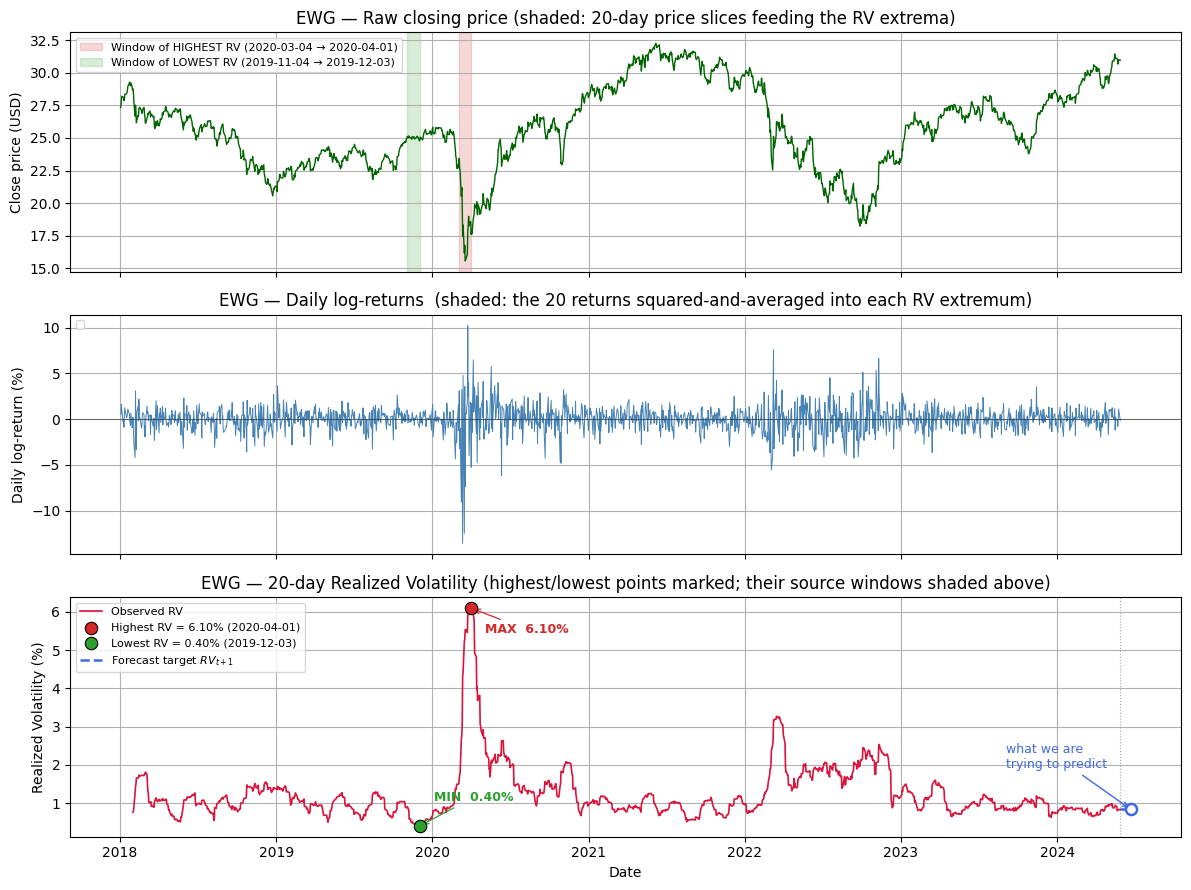

EWG price:        start=27.32  end=30.96  min=15.58  max=32.26
EWG return stats: mean=+0.0078%  std=1.4506%  min=-13.57%  max=+10.22%
EWG RV stats:     mean=1.2536  min=0.4024 (on 2019-12-03)  max=6.1006 (on 2020-04-01)
  → highest-RV source window: returns 2020-03-05 → 2020-04-01 (prices from 2020-03-04)
  → lowest-RV  source window: returns 2019-11-05 → 2019-12-03 (prices from 2019-11-04)


In [ ]:
TGT_DEMO = 'EWG'  # Germany — change to any ticker in TICKERS

# Identify the highest- and lowest-volatility points for this ETF, and the
# 20-day windows of returns/prices that were used to compute them. RV at date t
# is built from log-returns r_{t-19}..r_t, so the source window for an RV point
# is the 20 trading days ending at that date (and the corresponding price slice
# extends one day further back to give those 20 returns).
rv_series   = rv[TGT_DEMO]
rv_max_date = rv_series.idxmax()
rv_min_date = rv_series.idxmin()
rv_max_val  = rv_series.loc[rv_max_date]
rv_min_val  = rv_series.loc[rv_min_date]

def _window_bounds(end_date, n=WINDOW):
    # 20 returns ending at end_date -> log_ret indices [end_idx-19 .. end_idx]
    idx = log_ret.index.get_loc(end_date)
    ret_start = log_ret.index[max(idx - n + 1, 0)]
    ret_end   = log_ret.index[idx]
    # prices need one extra day on the left because r_t = ln(p_t/p_{t-1})
    p_idx     = raw.index.get_loc(ret_start)
    price_start = raw.index[max(p_idx - 1, 0)]
    price_end   = ret_end
    return price_start, price_end, ret_start, ret_end

p_hi_s, p_hi_e, r_hi_s, r_hi_e = _window_bounds(rv_max_date)
p_lo_s, p_lo_e, r_lo_s, r_lo_e = _window_bounds(rv_min_date)

HI_C = '#d62728'   # red  - highest vol window
LO_C = '#2ca02c'   # green - lowest vol window

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# --- Top: raw closing price ---
axes[0].plot(raw.index, raw[TGT_DEMO], color='darkgreen', linewidth=1.0)
axes[0].axvspan(p_hi_s, p_hi_e, color=HI_C, alpha=0.18,
                label=f'Window of HIGHEST RV ({p_hi_s.date()} → {p_hi_e.date()})')
axes[0].axvspan(p_lo_s, p_lo_e, color=LO_C, alpha=0.18,
                label=f'Window of LOWEST RV ({p_lo_s.date()} → {p_lo_e.date()})')
axes[0].set_ylabel('Close price (USD)')
axes[0].set_title(f'{TGT_DEMO} — Raw closing price (shaded: 20-day price slices feeding the RV extrema)')
axes[0].legend(loc='upper left', fontsize=8)

# --- Middle: daily log-returns ---
axes[1].plot(log_ret.index, log_ret[TGT_DEMO] * 100, color='steelblue', linewidth=0.7)
axes[1].axhline(0, color='black', linewidth=0.6, alpha=0.5)
#axes[1].axvspan(r_hi_s, r_hi_e, color=HI_C, alpha=0.22,
                #label='20 returns → HIGHEST RV')
#axes[1].axvspan(r_lo_s, r_lo_e, color=LO_C, alpha=0.22,
                #label='20 returns → LOWEST RV')
axes[1].set_ylabel('Daily log-return (%)')
axes[1].set_title(f'{TGT_DEMO} — Daily log-returns  (shaded: the 20 returns squared-and-averaged into each RV extremum)')
axes[1].legend(loc='upper left', fontsize=8)

# --- Bottom: 20-day realized volatility ---
axes[2].plot(rv.index, rv[TGT_DEMO], color='crimson', linewidth=1.2, label='Observed RV')

# Mark highest and lowest RV points explicitly
axes[2].scatter([rv_max_date], [rv_max_val], color=HI_C, s=80, zorder=5,
                edgecolor='black', linewidth=0.8,
                label=f'Highest RV = {rv_max_val:.2f}% ({rv_max_date.date()})')
axes[2].scatter([rv_min_date], [rv_min_val], color=LO_C, s=80, zorder=5,
                edgecolor='black', linewidth=0.8,
                label=f'Lowest RV = {rv_min_val:.2f}% ({rv_min_date.date()})')
axes[2].annotate(f'MAX  {rv_max_val:.2f}%',
                 xy=(rv_max_date, rv_max_val),
                 xytext=(10, -18), textcoords='offset points',
                 fontsize=9, color=HI_C, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=HI_C, lw=0.9))
axes[2].annotate(f'MIN  {rv_min_val:.2f}%',
                 xy=(rv_min_date, rv_min_val),
                 xytext=(10, 18), textcoords='offset points',
                 fontsize=9, color=LO_C, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=LO_C, lw=0.9))

# Dashed extension stemming from the end of the series — marks the forecast target RV_{t+1}
_last_date = rv.index[-1]
_last_val  = rv[TGT_DEMO].iloc[-1]
_future_date = _last_date + pd.Timedelta(days=25)
axes[2].plot([_last_date, _future_date], [_last_val, _last_val],
             color='royalblue', linewidth=1.8, linestyle='--',
             label=r'Forecast target $RV_{t+1}$')
axes[2].plot(_future_date, _last_val, marker='o', color='royalblue',
             markersize=8, markerfacecolor='white', markeredgewidth=1.8)
axes[2].axvline(_last_date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
axes[2].annotate('what we are\ntrying to predict',
                 xy=(_future_date, _last_val),
                 xytext=(-90, 30), textcoords='offset points',
                 fontsize=9, color='royalblue',
                 arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.0))
axes[2].legend(loc='upper left', fontsize=8)
axes[2].set_ylabel('Realized Volatility (%)')
axes[2].set_xlabel('Date')
axes[2].set_title(f'{TGT_DEMO} — 20-day Realized Volatility (highest/lowest points marked; their source windows shaded above)')

plt.tight_layout(); plt.show()

print(f'{TGT_DEMO} price:        start={raw[TGT_DEMO].iloc[0]:.2f}  '
      f'end={raw[TGT_DEMO].iloc[-1]:.2f}  '
      f'min={raw[TGT_DEMO].min():.2f}  max={raw[TGT_DEMO].max():.2f}')
print(f'{TGT_DEMO} return stats: mean={log_ret[TGT_DEMO].mean()*100:+.4f}%  '
      f'std={log_ret[TGT_DEMO].std()*100:.4f}%  min={log_ret[TGT_DEMO].min()*100:+.2f}%  '
      f'max={log_ret[TGT_DEMO].max()*100:+.2f}%')
print(f'{TGT_DEMO} RV stats:     mean={rv[TGT_DEMO].mean():.4f}  '
      f'min={rv[TGT_DEMO].min():.4f} (on {rv_min_date.date()})  '
      f'max={rv[TGT_DEMO].max():.4f} (on {rv_max_date.date()})')
print(f'  → highest-RV source window: returns {r_hi_s.date()} → {r_hi_e.date()} (prices from {p_hi_s.date()})')
print(f'  → lowest-RV  source window: returns {r_lo_s.date()} → {r_lo_e.date()} (prices from {p_lo_s.date()})')

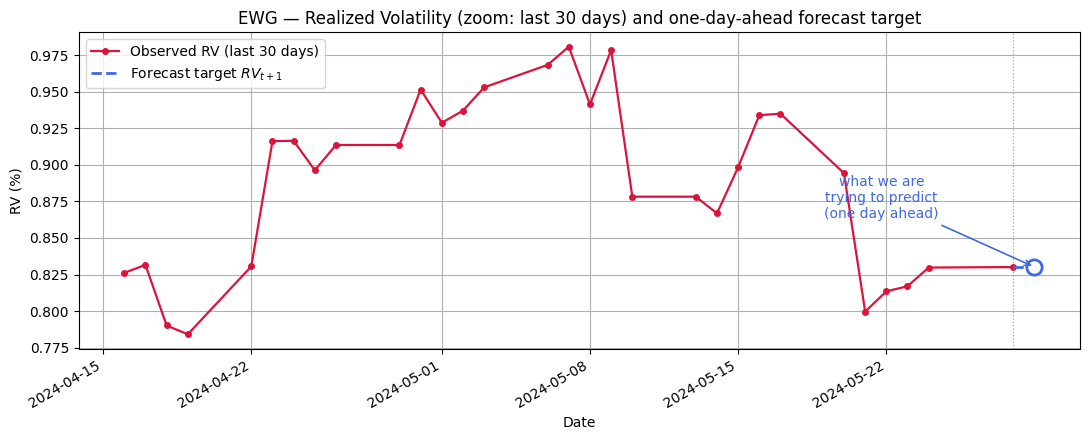

In [ ]:
# Zoomed-in view: last ~1 month of RV with the forecast target marker
ZOOM_DAYS = 30
rv_zoom = rv[TGT_DEMO].iloc[-ZOOM_DAYS:]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(rv_zoom.index, rv_zoom.values, color='crimson', linewidth=1.6,
        marker='o', markersize=4, label='Observed RV (last 30 days)')

# Dashed line stemming from the last observed point to the forecast target
last_date  = rv_zoom.index[-1]
last_val   = rv_zoom.iloc[-1]
next_date  = last_date + pd.tseries.offsets.BDay(1)

ax.plot([last_date, next_date], [last_val, last_val],
        color='royalblue', linewidth=2.0, linestyle='--',
        label=r'Forecast target $RV_{t+1}$')
ax.plot(next_date, last_val, marker='o', color='royalblue',
        markersize=11, markerfacecolor='white', markeredgewidth=2.0)
ax.axvline(last_date, color='gray', linestyle=':', linewidth=0.9, alpha=0.7)
ax.annotate('what we are\ntrying to predict\n(one day ahead)',
            xy=(next_date, last_val),
            xytext=(-110, 35), textcoords='offset points',
            fontsize=10, color='royalblue', ha='center',
            arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.2))

ax.set_title(f'{TGT_DEMO} — Realized Volatility (zoom: last {ZOOM_DAYS} days) and one-day-ahead forecast target')
ax.set_ylabel('RV (%)'); ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()

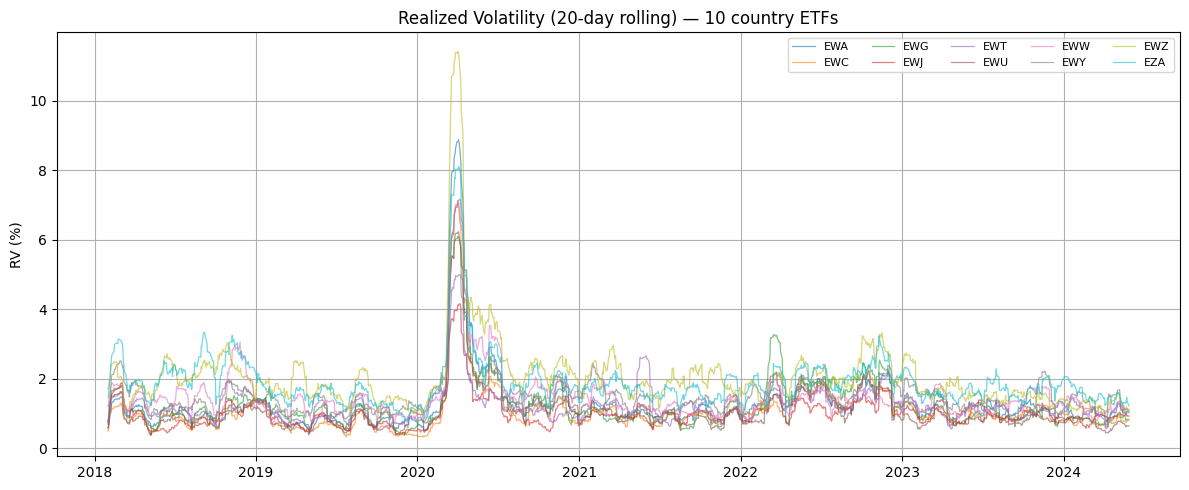

In [ ]:
# Visualize realized volatility — the COVID-19 crisis spike should be obvious
fig, ax = plt.subplots(figsize=(12, 5))
for t in TICKERS:
    ax.plot(rv.index, rv[t], alpha=0.6, label=t, linewidth=0.9)
ax.set_title('Realized Volatility (20-day rolling) — 10 country ETFs')
ax.set_ylabel('RV (%)')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

## 4. Hurst exponent — regime detection

We compute a rolling Hurst exponent on the MSCI World proxy via Rescaled-Range (R/S) analysis:
- $H > 0.5$ → persistent (calm) regime
- $H < 0.5$ → anti-persistent (crisis-like) regime
- $H \approx 0.5$ → random walk


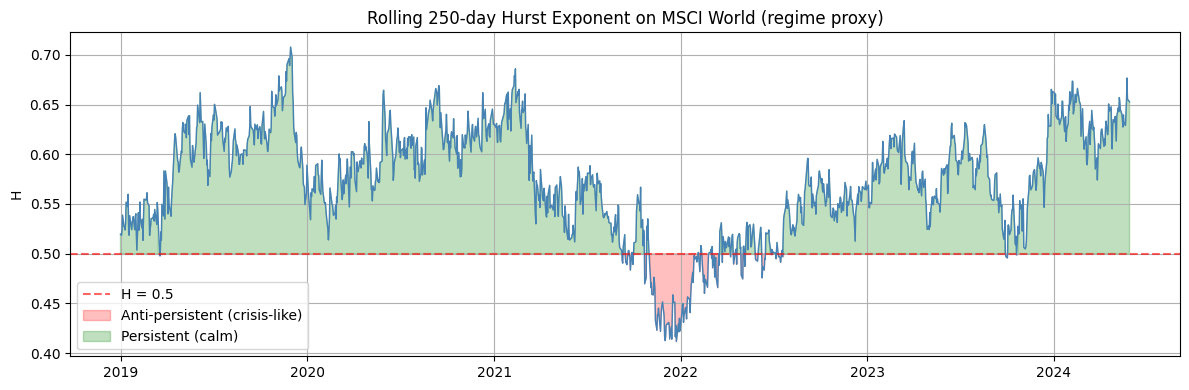

Days persistent (H>0.5): 1231
Days anti-persistent (H<0.5): 130


In [ ]:
def hurst_rs(series):
    """Rescaled-range Hurst exponent estimator."""
    series = np.asarray(series, dtype=float)
    N = len(series)
    if N < 20:
        return np.nan
    lags = np.unique(np.logspace(1, np.log10(N // 2), 10).astype(int))
    rs = []
    for lag in lags:
        chunks = N // lag
        if chunks < 1:
            continue
        rs_vals = []
        for j in range(chunks):
            seg = series[j*lag:(j+1)*lag]
            mean = seg.mean()
            dev = np.cumsum(seg - mean)
            R = dev.max() - dev.min()
            S = seg.std(ddof=1)
            if S > 0:
                rs_vals.append(R / S)
        if rs_vals:
            rs.append((lag, np.mean(rs_vals)))
    if len(rs) < 2:
        return np.nan
    lags_arr, rs_arr = zip(*rs)
    H, _ = np.polyfit(np.log(lags_arr), np.log(rs_arr), 1)
    return H

ROLL = 250
world_ret = log_ret[REGIME_PROXY]
hurst_series = world_ret.rolling(ROLL).apply(hurst_rs, raw=True)
hurst_series = hurst_series.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hurst_series.index, hurst_series.values, color='steelblue', linewidth=1)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='H = 0.5')
ax.fill_between(hurst_series.index, hurst_series.values, 0.5,
                where=(hurst_series.values < 0.5), alpha=0.25, color='red',
                label='Anti-persistent (crisis-like)')
ax.fill_between(hurst_series.index, hurst_series.values, 0.5,
                where=(hurst_series.values >= 0.5), alpha=0.25, color='green',
                label='Persistent (calm)')
ax.set_title('Rolling 250-day Hurst Exponent on MSCI World (regime proxy)')
ax.set_ylabel('H'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Days persistent (H>0.5): {(hurst_series>=0.5).sum()}")
print(f"Days anti-persistent (H<0.5): {(hurst_series<0.5).sum()}")

## 5. Effective Rényi Transfer Entropy (ER-TE)

We implement the **Leonenko–Pronzato–Savani (LPS)** k-NN estimator for Rényi entropy of order $\alpha \neq 1$:

$$\hat{H}_\alpha = \frac{1}{1-\alpha}\log_2\!\left[ C_k \cdot (N-1)^{1-\alpha} \cdot B_d^{1-\alpha} \cdot \frac{1}{N}\sum_{i=1}^{N} \rho_i^{d(1-\alpha)} \right]$$

Then RTE from $Y \to X$ is built from conditional Rényi entropies, and **ER-TE** subtracts the mean RTE over $m$ shuffled surrogates of $Y$ to remove finite-sample bias.


In [ ]:
def lps_renyi_entropy(X, alpha, k=3):
    """LPS k-NN estimator of Rényi entropy of order alpha.
    X: (N, d) array. Returns H_alpha in nats (log base e). For alpha~1 falls back to k-NN Shannon.
    """
    X = np.atleast_2d(X)
    if X.shape[1] == 1 and X.shape[0] > 1:
        pass
    elif X.ndim == 1:
        X = X.reshape(-1, 1)
    N, d = X.shape
    if N <= k + 1:
        return np.nan
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    dists, _ = nbrs.kneighbors(X)
    rho = dists[:, k]  # distance to k-th nearest neighbor (excluding self)
    rho = np.where(rho <= 0, 1e-12, rho)
    B_d = np.pi**(d/2) / gamma_fn(d/2 + 1)  # volume of unit d-ball
    if abs(alpha - 1.0) < 1e-6:
        # Kozachenko-Leonenko Shannon entropy estimator
        from scipy.special import digamma
        return -digamma(k) + digamma(N) + np.log(B_d) + d * np.mean(np.log(rho))
    C_k = (gamma_fn(k) / gamma_fn(k + 1 - alpha))**(1/(1-alpha))
    inner = (C_k**(1-alpha)) * ((N-1)**(1-alpha)) * (B_d**(1-alpha)) * np.mean(rho**(d*(1-alpha)))
    inner = max(inner, 1e-300)
    return (1.0/(1.0-alpha)) * np.log(inner)

def renyi_te(y, x, alpha, k=3, lag=1):
    """Rényi Transfer Entropy from Y -> X with k=l=lag=1.
    T = H(X_{t+1} | X_t) - H(X_{t+1} | X_t, Y_t)
      = [H(X_{t+1},X_t) - H(X_t)] - [H(X_{t+1},X_t,Y_t) - H(X_t,Y_t)]
    """
    y = np.asarray(y); x = np.asarray(x)
    Xt   = x[lag:-0 if lag==0 else None][:-1]  # not used; we build joint manually below
    Xtp1 = x[lag+1:]
    Xt   = x[lag:-1]
    Yt   = y[lag:-1]
    n = len(Xtp1)
    Xt = Xt[:n]; Yt = Yt[:n]
    H_x      = lps_renyi_entropy(Xt.reshape(-1,1), alpha, k)
    H_xy     = lps_renyi_entropy(np.column_stack([Xt, Yt]), alpha, k)
    H_xtp1_x = lps_renyi_entropy(np.column_stack([Xtp1, Xt]), alpha, k)
    H_full   = lps_renyi_entropy(np.column_stack([Xtp1, Xt, Yt]), alpha, k)
    # H(X_{t+1}|X_t) = H(X_{t+1},X_t) - H(X_t)
    # H(X_{t+1}|X_t,Y_t) = H(X_{t+1},X_t,Y_t) - H(X_t,Y_t)
    return (H_xtp1_x - H_x) - (H_full - H_xy)

def effective_rte(y, x, alpha, k=3, m_shuffles=20, seed=0):
    """ER-TE = RTE(Y->X) - mean(RTE(Y_shuffled->X)). Returns (ERTE, Z-score)."""
    rng = np.random.default_rng(seed)
    rte_obs = renyi_te(y, x, alpha, k=k)
    surr = []
    for _ in range(m_shuffles):
        y_s = rng.permutation(y)
        surr.append(renyi_te(y_s, x, alpha, k=k))
    surr = np.array(surr)
    bias = np.nanmean(surr)
    sd = np.nanstd(surr) + 1e-9
    erte = rte_obs - bias
    z = (rte_obs - bias) / sd
    return erte, z

# quick sanity check on one pair
_test = effective_rte(log_ret['EWG'].values[-500:], log_ret['EWJ'].values[-500:], alpha=1.0, m_shuffles=10)
print(f"EWG -> EWJ Shannon ER-TE on last 500 days: ERTE={_test[0]:.4f}, Z={_test[1]:.2f}")

EWG -> EWJ Shannon ER-TE on last 500 days: ERTE=-0.0095, Z=-0.18


### Build the ER-TE adjacency matrix

For each ordered pair $(Y, X)$, we compute ER-TE and retain edges with $Z > 1.96$ (5% significance).


Building Shannon ER-TE adjacency (alpha=1.0)...
Building Rényi ER-TE adjacency (alpha=0.5, tail-emphasizing)...


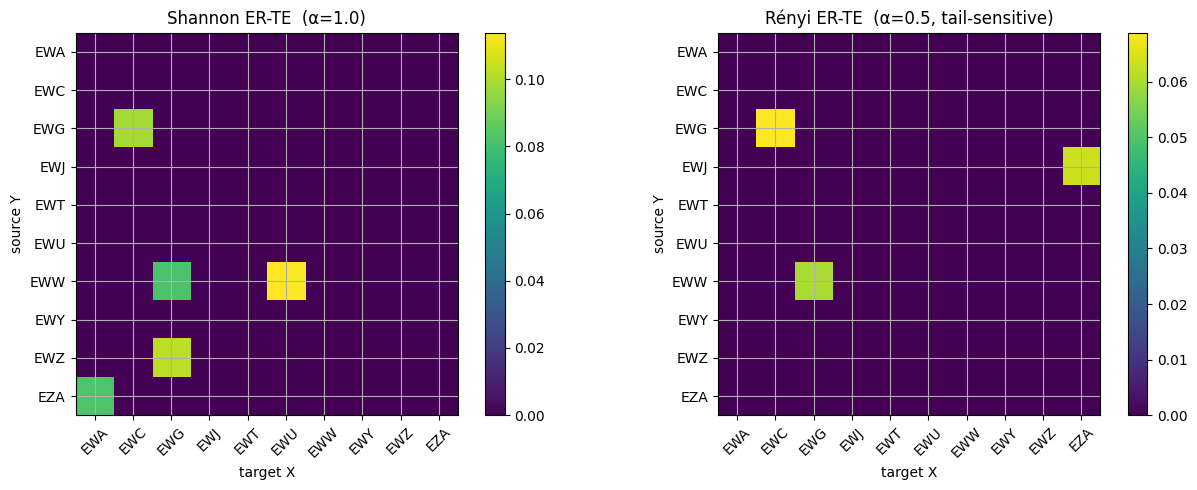

Shannon edges retained:  5/90
Rényi   edges retained:  3/90


In [ ]:
def build_erte_adjacency(returns_df, tickers, alpha, m_shuffles=20, k=3, z_thresh=1.96):
    n = len(tickers)
    A = np.zeros((n, n))
    Z = np.zeros((n, n))
    for i, ti in enumerate(tickers):       # source Y
        for j, tj in enumerate(tickers):   # target X
            if i == j: continue
            erte, z = effective_rte(returns_df[ti].values, returns_df[tj].values,
                                    alpha=alpha, k=k, m_shuffles=m_shuffles,
                                    seed=i*100+j)
            Z[i,j] = z
            if z > z_thresh and np.isfinite(erte):
                A[i,j] = max(erte, 0.0)
    return A, Z

# Use a recent window for the demo (last 600 trading days)
window_returns = log_ret[TICKERS].iloc[-600:]

print("Building Shannon ER-TE adjacency (alpha=1.0)...")
A_shannon, Z_shannon = build_erte_adjacency(window_returns, TICKERS, alpha=1.0, m_shuffles=20)
print("Building Rényi ER-TE adjacency (alpha=0.5, tail-emphasizing)...")
A_renyi05, Z_renyi05 = build_erte_adjacency(window_returns, TICKERS, alpha=0.5, m_shuffles=20)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, A, ttl in zip(axes, [A_shannon, A_renyi05],
                       ['Shannon ER-TE  (α=1.0)', 'Rényi ER-TE  (α=0.5, tail-sensitive)']):
    im = ax.imshow(A, cmap='viridis')
    ax.set_xticks(range(len(TICKERS))); ax.set_xticklabels(TICKERS, rotation=45)
    ax.set_yticks(range(len(TICKERS))); ax.set_yticklabels(TICKERS)
    ax.set_title(ttl); ax.set_xlabel('target X'); ax.set_ylabel('source Y')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print(f"Shannon edges retained:  {(A_shannon>0).sum()}/{len(TICKERS)*(len(TICKERS)-1)}")
print(f"Rényi   edges retained:  {(A_renyi05>0).sum()}/{len(TICKERS)*(len(TICKERS)-1)}")

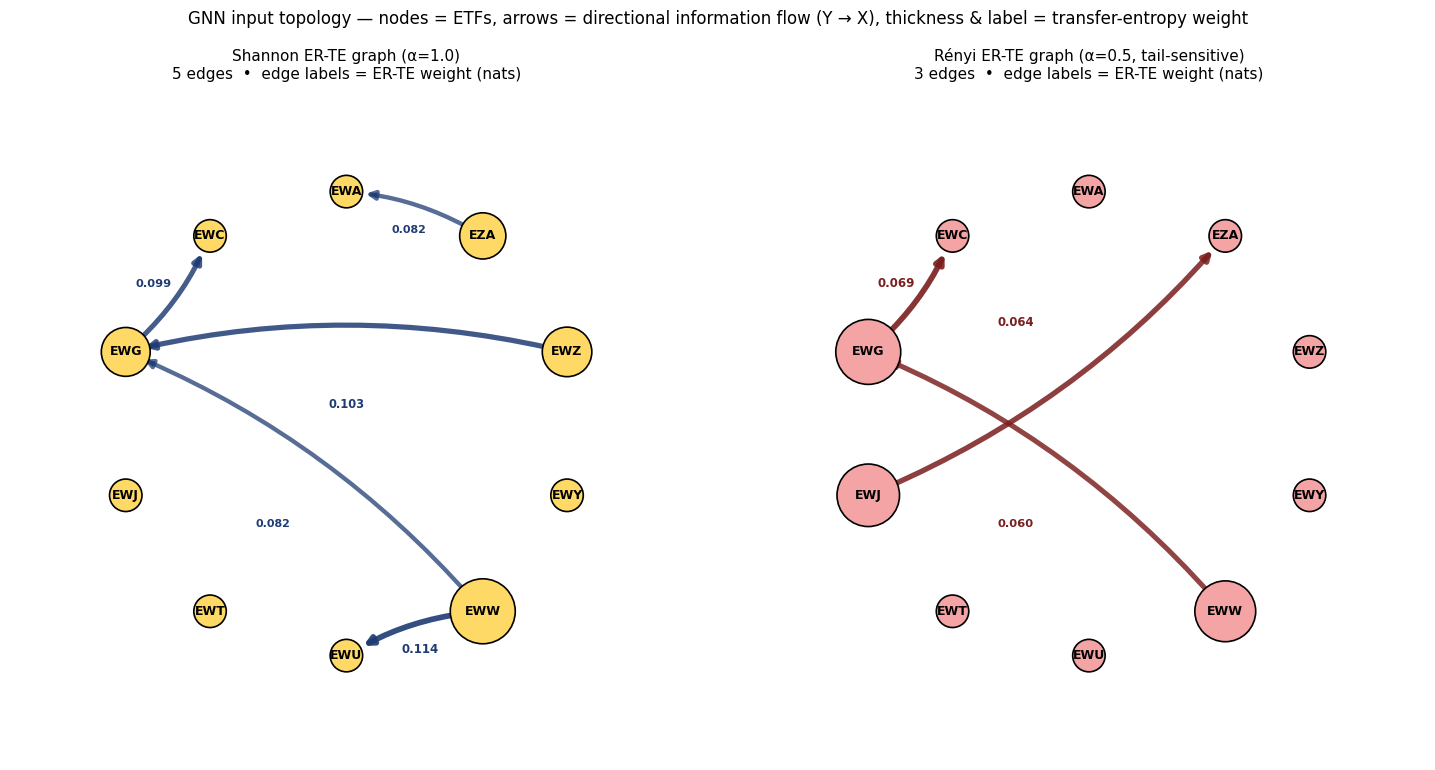

Top-10 strongest edges  —  Shannon ER-TE (α = 1.0)
source Y target X  ER-TE weight
     EWW      EWU        0.1138
     EWZ      EWG        0.1026
     EWG      EWC        0.0985
     EZA      EWA        0.0825
     EWW      EWG        0.0816

Top-10 strongest edges  —  Rényi ER-TE (α = 0.5)
source Y target X  ER-TE weight
     EWG      EWC        0.0688
     EWJ      EZA        0.0636
     EWW      EWG        0.0601


In [ ]:
from matplotlib.patches import FancyArrowPatch, Circle

def draw_directed_graph(ax, A, labels, title, node_color='#ffd966', edge_color='#1f3b73',
                        show_weights=True, weight_fmt='{:.3f}'):
    n = len(labels)
    # Circular layout
    angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n, endpoint=False)
    pos = {i: (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}

    out_strength = A.sum(axis=1)
    max_w = A.max() if A.max() > 0 else 1.0
    max_out = out_strength.max() if out_strength.max() > 0 else 1.0

    # Draw edges
    for i in range(n):
        for j in range(n):
            if A[i, j] <= 0 or i == j:
                continue
            x0, y0 = pos[i]; x1, y1 = pos[j]
            w = A[i, j]
            lw = 0.6 + 3.5 * (w / max_w)
            alpha = 0.35 + 0.55 * (w / max_w)
            arrow = FancyArrowPatch(
                (x0, y0), (x1, y1),
                arrowstyle='-|>', mutation_scale=12,
                connectionstyle='arc3,rad=0.12',
                color=edge_color, alpha=alpha, linewidth=lw,
                shrinkA=14, shrinkB=14,
            )
            ax.add_patch(arrow)

            if show_weights:
                # Label position: midpoint nudged perpendicular to match the
                # arc curvature (rad=0.12) so the text sits on the arc.
                mx, my = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
                dx, dy = x1 - x0, y1 - y0
                # perpendicular (left of direction), matching positive rad curvature
                perp = np.array([-dy, dx])
                perp = perp / (np.linalg.norm(perp) + 1e-9)
                offset = 0.12 * np.linalg.norm([dx, dy])
                tx, ty = mx + perp[0] * offset, my + perp[1] * offset
                # Strong edges get a slightly bigger / bolder label
                rel = w / max_w
                fs = 6.5 + 2.0 * rel
                ax.text(tx, ty, weight_fmt.format(w),
                        fontsize=fs, color=edge_color,
                        fontweight='bold' if rel > 0.6 else 'normal',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.15',
                                  facecolor='white', edgecolor='none', alpha=0.78),
                        zorder=5)

    # Draw nodes
    for i, lab in enumerate(labels):
        x, y = pos[i]
        r = 0.07 + 0.07 * (out_strength[i] / max_out)
        circ = Circle((x, y), r, facecolor=node_color, edgecolor='black',
                      linewidth=1.2, zorder=3)
        ax.add_patch(circ)
        ax.text(x, y, lab, ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=4)

    ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
draw_directed_graph(axes[0], A_shannon, TICKERS,
                    f'Shannon ER-TE graph (α=1.0)\n{(A_shannon>0).sum()} edges  •  edge labels = ER-TE weight (nats)',
                    node_color='#ffd966', edge_color='#1f3b73')
draw_directed_graph(axes[1], A_renyi05, TICKERS,
                    f'Rényi ER-TE graph (α=0.5, tail-sensitive)\n{(A_renyi05>0).sum()} edges  •  edge labels = ER-TE weight (nats)',
                    node_color='#f4a4a4', edge_color='#7a1e1e')
plt.suptitle('GNN input topology — nodes = ETFs, arrows = directional information flow (Y → X), '
             'thickness & label = transfer-entropy weight',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# Companion table: top transfer-entropy edges so the panel can read exact values
def _top_edges(A, labels, k=10):
    rows = []
    n = len(labels)
    for i in range(n):
        for j in range(n):
            if A[i, j] > 0 and i != j:
                rows.append((labels[i], labels[j], A[i, j]))
    rows.sort(key=lambda r: r[2], reverse=True)
    return pd.DataFrame(rows[:k], columns=['source Y', 'target X', 'ER-TE weight'])

print('Top-10 strongest edges  —  Shannon ER-TE (α = 1.0)')
print(_top_edges(A_shannon, TICKERS).to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nTop-10 strongest edges  —  Rényi ER-TE (α = 0.5)')
print(_top_edges(A_renyi05, TICKERS).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

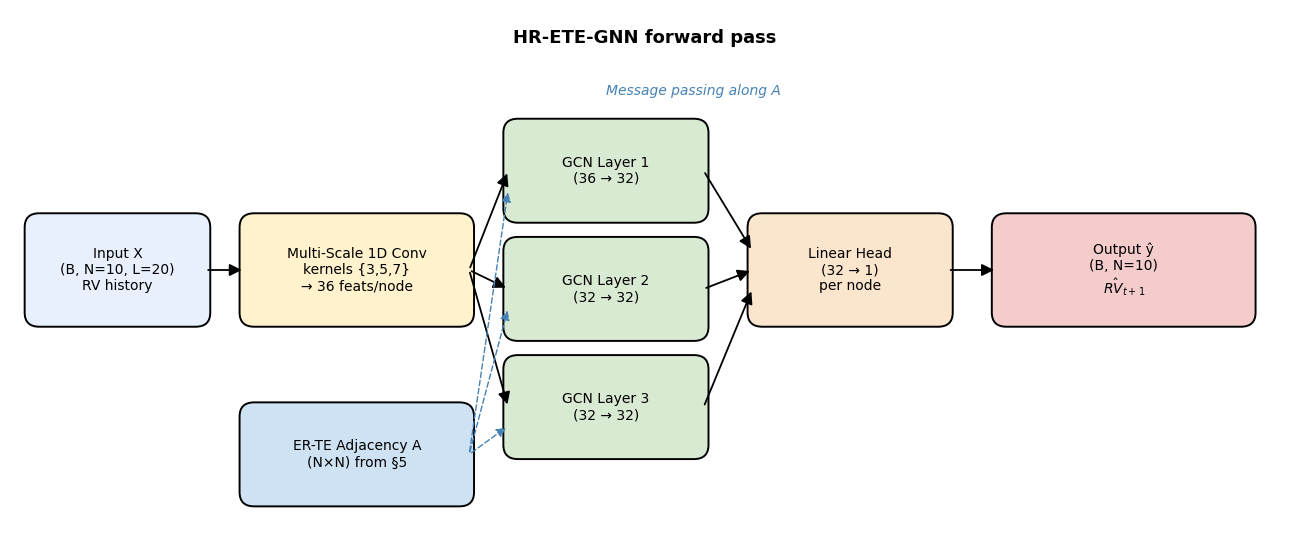

In [ ]:
# Visualize the HR-ETE-GNN architecture as a block diagram
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.5); ax.axis('off')

def block(x, y, w, h, text, fc, ec='black'):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05,rounding_size=0.15",
                       facecolor=fc, edgecolor=ec, linewidth=1.4)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10)

def arrow(x0, y0, x1, y1):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                                 mutation_scale=18, color='black', linewidth=1.3))

# Pipeline blocks
block(0.2, 2.2, 1.8, 1.1,
      "Input X\n(B, N=10, L=20)\nRV history",       '#e8f0fe')
block(2.4, 2.2, 2.3, 1.1,
      "Multi-Scale 1D Conv\nkernels {3,5,7}\n→ 36 feats/node", '#fff2cc')
block(5.1, 3.3, 2.0, 1.0,  "GCN Layer 1\n(36 → 32)",  '#d9ead3')
block(5.1, 2.05, 2.0, 1.0, "GCN Layer 2\n(32 → 32)",  '#d9ead3')
block(5.1, 0.8, 2.0, 1.0,  "GCN Layer 3\n(32 → 32)",  '#d9ead3')
block(7.6, 2.2, 2.0, 1.1,
      "Linear Head\n(32 → 1)\nper node",               '#fce5cd')
block(10.1, 2.2, 2.6, 1.1,
      r"Output ŷ"  + "\n(B, N=10)\n" + r"$\hat{RV}_{t+1}$",  '#f4cccc')

# Adjacency input feeding all GCN layers
block(2.4, 0.3, 2.3, 1.0,
      "ER-TE Adjacency A\n(N×N) from §5",              '#cfe2f3')

# Forward arrows
arrow(2.0, 2.75, 2.4, 2.75)
arrow(4.7, 2.75, 5.1, 3.8)
arrow(4.7, 2.75, 5.1, 2.55)
arrow(4.7, 2.75, 5.1, 1.3)
arrow(7.1, 3.8, 7.6, 2.95)
arrow(7.1, 2.55, 7.6, 2.75)
arrow(7.1, 1.3, 7.6, 2.55)
arrow(9.6, 2.75, 10.1, 2.75)

# A → each GCN layer (dashed, blue)
def dashed(x0, y0, x1, y1):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                                 mutation_scale=14, color='steelblue',
                                 linewidth=1.0, linestyle=(0, (4, 2))))
dashed(4.7, 0.8, 5.1, 3.6)
dashed(4.7, 0.8, 5.1, 2.35)
dashed(4.7, 0.8, 5.1, 1.1)

ax.text(6.1, 4.6, "Message passing along A", color='steelblue',
        fontsize=10, fontstyle='italic')
ax.text(6.5, 5.15, "HR-ETE-GNN forward pass",
        ha='center', fontsize=13, fontweight='bold')

plt.tight_layout(); plt.show()

# Also print the actual instantiated PyTorch module for reference
#demo_model = HRETEGNN(n_nodes=len(TICKERS), lookback=LOOKBACK, hidden=32)
#n_params = sum(p.numel() for p in demo_model.parameters())
#print(f"Total trainable parameters: {n_params:,}\n")
#print(demo_model)

## 6. The Hybrid GCN forecasting model

Architecture (following Lee & Cho 2025):
1. **Multi-scale 1D conv** over each node's recent RV history (kernels {3,5,7})
2. **3 GCN layers** that propagate node features along the ER-TE adjacency
3. **Linear head** → one-day-ahead RV prediction per node

In [ ]:
class MultiScaleConv(nn.Module):
    def __init__(self, in_len, channels=12, kernels=(3,5,7)):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(1, channels, kernel_size=k, padding=k//2) for k in kernels
        ])
        self.out_dim = channels * len(kernels)
    def forward(self, x):
        # x: (B, n_nodes, in_len)
        B, N, L = x.shape
        x = x.reshape(B*N, 1, L)
        feats = [F.relu(c(x)) for c in self.convs]
        feats = [f.mean(dim=2) for f in feats]   # global avg pool over time
        out = torch.cat(feats, dim=1)            # (B*N, channels*len(kernels))
        return out.view(B, N, -1)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W1 = nn.Linear(in_dim, out_dim)
        self.W2 = nn.Linear(in_dim, out_dim)
    def forward(self, H, A):
        # H: (B, N, F), A: (N, N)
        return F.relu(self.W1(H) + torch.einsum('ij,bjf->bif', A, self.W2(H)))

class HRETEGNN(nn.Module):
    def __init__(self, n_nodes, lookback, hidden=32):
        super().__init__()
        self.feat = MultiScaleConv(lookback)
        d = self.feat.out_dim
        self.g1 = GCNLayer(d, hidden)
        self.g2 = GCNLayer(hidden, hidden)
        self.g3 = GCNLayer(hidden, hidden)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x, A):
        h = self.feat(x)
        h = self.g1(h, A); h = self.g2(h, A); h = self.g3(h, A)
        return self.head(h).squeeze(-1)   # (B, N)

## 7. Build training samples and train

**Inputs (X):** for each day $t$, the past 20-day RV history of all 10 nodes → tensor of shape (n_nodes, lookback).
**Target (y):** $RV_{t+1}$ for all 10 nodes.

In [ ]:
LOOKBACK = 20
rv_mat = rv[TICKERS].values  # (T, n_nodes)

Xs, ys = [], []
for t in range(LOOKBACK, len(rv_mat)-1):
    Xs.append(rv_mat[t-LOOKBACK:t].T)   # (n_nodes, lookback)
    ys.append(rv_mat[t+1])
Xs = np.stack(Xs); ys = np.stack(ys)

split = int(0.8 * len(Xs))
X_train, X_test = Xs[:split], Xs[split:]
y_train, y_test = ys[:split], ys[split:]
print(f"Train: {X_train.shape},  Test: {X_test.shape}")

# normalize adjacency (row-stochastic)
def row_normalize(A):
    s = A.sum(axis=1, keepdims=True); s[s==0] = 1.0
    return A / s

def train_model(A_np, label, epochs=50, lr=1e-3):
    A = torch.tensor(row_normalize(A_np), dtype=torch.float32)
    model = HRETEGNN(n_nodes=len(TICKERS), lookback=LOOKBACK, hidden=32)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xte = torch.tensor(X_test,  dtype=torch.float32)
    yte = torch.tensor(y_test,  dtype=torch.float32)
    history = []
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        pred = model(Xtr, A)
        loss = F.mse_loss(pred, ytr)
        loss.backward(); opt.step()
        history.append(loss.item())
    model.eval()
    with torch.no_grad():
        pred_te = model(Xte, A).numpy()
    rmse = float(np.sqrt(np.mean((pred_te - y_test)**2)))
    mae  = float(np.mean(np.abs(pred_te - y_test)))
    print(f"[{label}]  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return {'label': label, 'rmse': rmse, 'mae': mae,
            'pred': pred_te, 'history': history, 'A': A_np}

results = {}
results['Shannon ETE-GNN (α=1)'] = train_model(A_shannon,  'Shannon ETE-GNN (α=1)')
results['Rényi   ETE-GNN (α=0.5)'] = train_model(A_renyi05, 'Rényi   ETE-GNN (α=0.5)')

Train: (1256, 10, 20),  Test: (314, 10, 20)
[Shannon ETE-GNN (α=1)]  RMSE=0.2384  MAE=0.1847
[Rényi   ETE-GNN (α=0.5)]  RMSE=0.2053  MAE=0.1567


## 8. Compare forecasts vs. actual RV

Plot the test-set predictions for one representative ETF under both adjacency choices.

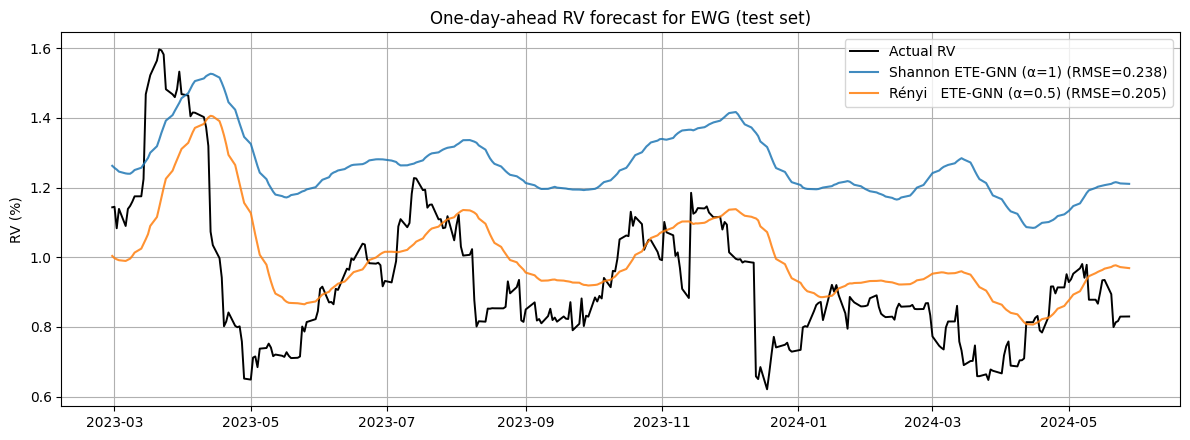

,RMSE,MAE,edges
Shannon ETE-GNN (α=1),0.238358,0.184675,5.0
Rényi ETE-GNN (α=0.5),0.205295,0.156685,3.0


In [ ]:
TGT = 'EWG'  # Germany
j = TICKERS.index(TGT)
test_dates = rv.index[LOOKBACK + 1 + split : LOOKBACK + 1 + split + len(y_test)]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test_dates, y_test[:, j], label='Actual RV', color='black', linewidth=1.4)
for label, r in results.items():
    ax.plot(test_dates, r['pred'][:, j], label=f"{label} (RMSE={r['rmse']:.3f})", alpha=0.85)
ax.set_title(f'One-day-ahead RV forecast for {TGT} (test set)')
ax.set_ylabel('RV (%)'); ax.legend()
plt.tight_layout(); plt.show()

summary = pd.DataFrame({k: {'RMSE': v['rmse'], 'MAE': v['mae'],
                            'edges': int((v['A']>0).sum())}
                        for k, v in results.items()}).T
summary

## 9. Topology comparison — who transmits the most information?

Out-strength = $\sum_j A_{ij}$, the total information broadcast by node $i$. Differences between Shannon and Rényi rankings answer **RQ2** in the manuscript.

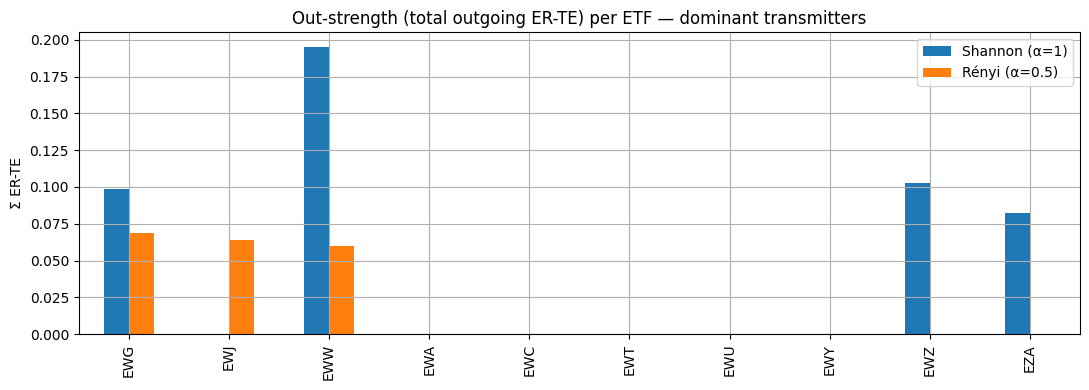

,Shannon (α=1),Rényi (α=0.5)
EWG,0.098520,0.068804
EWJ,0.000000,0.063624
EWW,0.195419,0.060082
EWA,0.000000,0.000000
EWC,0.000000,0.000000
EWT,0.000000,0.000000
EWU,0.000000,0.000000
EWY,0.000000,0.000000
EWZ,0.102622,0.000000
EZA,0.082468,0.000000


In [ ]:
out_sh = pd.Series(A_shannon.sum(axis=1),  index=TICKERS, name='Shannon (α=1)')
out_re = pd.Series(A_renyi05.sum(axis=1),  index=TICKERS, name='Rényi (α=0.5)')
topo = pd.concat([out_sh, out_re], axis=1).sort_values('Rényi (α=0.5)', ascending=False)

ax = topo.plot.bar(figsize=(11, 4))
ax.set_title('Out-strength (total outgoing ER-TE) per ETF — dominant transmitters')
ax.set_ylabel('Σ ER-TE')
plt.tight_layout(); plt.show()
topo

## 10. Takeaways for the panel

1. **Volatility is forecastable** — RV exhibits clustering and cross-asset spillovers (visible in §3).
2. **The pipeline runs end-to-end** — yfinance → log-returns → RV → Hurst regime → ER-TE adjacency → GCN → forecast.
3. **Rényi vs. Shannon graphs differ** — the adjacency heatmaps and the dominant-transmitter ranking differ between $\alpha=1$ and $\alpha=0.5$, which is the precondition for the Rényi extension to add value.
4. **Pilot caveat** — small data, small surrogate count, no Bayesian hyperparameter search, no rolling regime retraining. The full thesis run (19 years, 7-point α grid, full retraining) is required for the statistical significance claims.
5. **Next steps for the full study** — Bayesian optimization on the α-grid, regime-stratified RMSE/MAE/QLIKE, Diebold–Mariano significance vs. baselines, Kupiec/Christoffersen VaR backtests.